In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

rcparams = {
           "savefig.bbox" : "tight",
           "agg.path.chunksize" : 10000,
           "font.family" : "serif",
           "font.size" : 22,
           "legend.fontsize" : 16,
           "legend.loc" : "upper right",
           "mathtext.fontset" : "stix",
           "text.usetex" : True,

           # Set x axis
           "xtick.direction" : "in",
           "xtick.major.size" : 6,
           "xtick.major.width" : 1,
           "xtick.minor.size" : 3,
           "xtick.minor.width" : 1,
           "xtick.minor.visible" : True,
           "xtick.top" : True,

           # Set y axis
           "ytick.direction" : "in",
           "ytick.major.size" : 6,
           "ytick.major.width" : 1,
           "ytick.minor.size" : 3,
           "ytick.minor.width" : 1,
           "ytick.minor.visible" : True,
           "ytick.right" : True,

           # Set line widths
           "axes.linewidth" : 0.5,
           "grid.linewidth" : 0.5,
           "lines.linewidth" : 1.,

           # Grid lines
           "axes.grid" : True,
           "axes.axisbelow" : True,
           "grid.linestyle" : "--",
           "grid.color" : "k",
           "grid.alpha" : 0.5,
           "grid.linewidth" : 0.5,

           # Legend
           "legend.frameon" : True,
           "legend.framealpha" : 1.0,
           "legend.fancybox" : True,
           "legend.numpoints" : 1,

           # Fontsizes
           "xtick.labelsize" : 16,
           "ytick.labelsize" : 16,
           "legend.fontsize" : 16,
           "legend.title_fontsize" : 16,
           "axes.titlesize" : 16,
           "axes.labelsize" : 16,
           }

mpl.rcParams.update(rcparams)

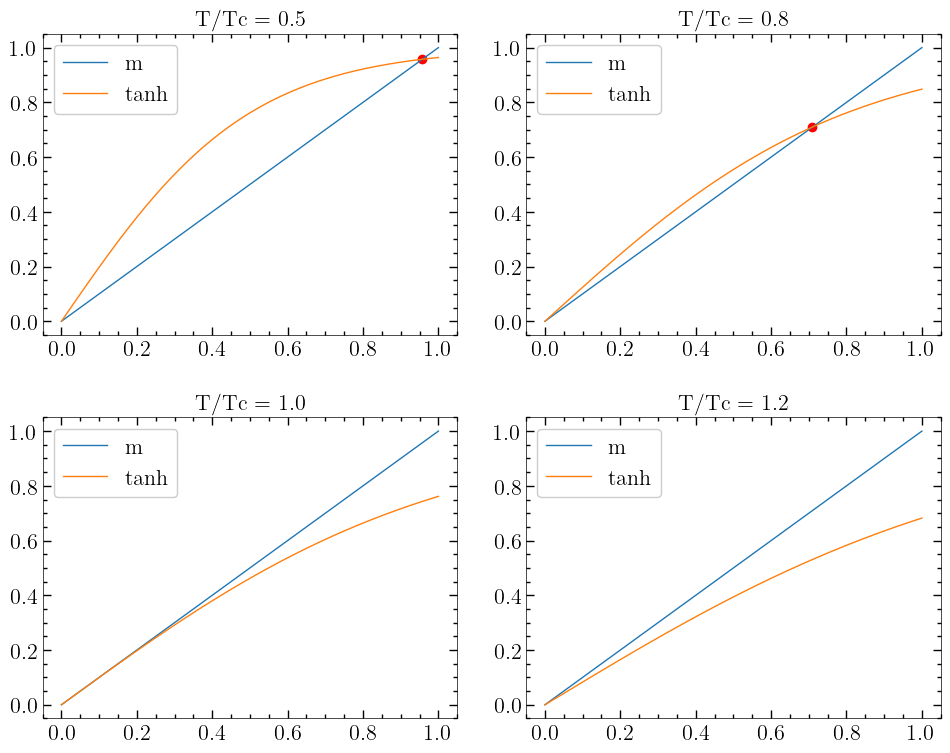

In [2]:
T_c = 1.0
temps = [0.5, 0.8, 1.0, 1.2]  # T/Tc values

m_vals = np.linspace(0, 1, 1000)

def solve_m(T_ratio):
    Tc_over_T = 1 / T_ratio
    rhs = np.tanh(Tc_over_T * m_vals)

    # find intersections numerically
    diff = rhs - m_vals

    # crude root estimate: sign change
    roots = []
    for i in range(len(diff)-1):
        if diff[i]*diff[i+1] < 0:
            roots.append(m_vals[i])
    return roots

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, T_ratio in zip(axes.flatten(), temps):
    Tc_over_T = 1 / T_ratio

    ax.plot(m_vals, m_vals, label="m")
    ax.plot(m_vals, np.tanh(Tc_over_T * m_vals), label="tanh")

    roots = solve_m(T_ratio)
    ax.scatter(roots, roots, color='red')

    ax.set_title(f"T/Tc = {T_ratio}")
    ax.legend(loc="best")
    ax.grid()

plt.tight_layout()
plt.savefig("Ising.png", dpi=300)
plt.show()

In [3]:
import pandas as pd

def solve_m(t, tol=1e-12, max_iter=10000):
    """
    Solve m = tanh(m/t) using fixed-point iteration.
    Returns magnetization <s> = m.
    """

    if t >= 1.0:
        return 0.0

    # start from ordered phase seed
    m = 0.8

    for _ in range(max_iter):
        m_new = np.tanh(m / t)
        if abs(m_new - m) < tol:
            return m_new
        m = m_new

    return m  # fallback

# temperature ratios T/Tc
t_values = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2])

results = []

for t in t_values:
    m = solve_m(t)
    results.append([t, m])

df = pd.DataFrame(results, columns=["T/Tc", "<s>"])

print(df)

   T/Tc       <s>
0   0.2  0.999909
1   0.4  0.985624
2   0.6  0.907332
3   0.8  0.710412
4   1.0  0.000000
5   1.2  0.000000


In [4]:
latex_table = df.to_latex(index=False, float_format="%.6f")
print(latex_table)

\begin{tabular}{rr}
\toprule
T/Tc & <s> \\
\midrule
0.200000 & 0.999909 \\
0.400000 & 0.985624 \\
0.600000 & 0.907332 \\
0.800000 & 0.710412 \\
1.000000 & 0.000000 \\
1.200000 & 0.000000 \\
\bottomrule
\end{tabular}

